Task 2: Yield Curve Modeling

In [80]:
# Task 2
! pip install fredapi


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\Keegan Vaughn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [81]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [82]:
# Initialize the FRED API with your key
fred = Fred(api_key='YOUR_FRED_API_KEY')

# List of Treasury yield series IDs
series_ids = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', \
              'DGS7', 'DGS10', 'DGS20', 'DGS30']

# Function to get data for a single series
def get_yield_data(series_id):
    data = fred.get_series(series_id, observation_start="1993-01-01", observation_end="2024-01-01")
    return data

# Get data for all series
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}

# Combine into a single DataFrame
yields = pd.DataFrame(yields_dict)

# Rename columns for clarity
yields.columns = ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year', '5 Year', \
                  '7 Year', '10 Year', '20 Year', '30 Year']

KeyboardInterrupt: 

In [36]:
yields.index = pd.to_datetime(yields.index)

In [37]:
yields = yields.dropna()
y_std = yields.std()
y_std

1 Month    1.642653
3 Month    1.676190
6 Month    1.699019
1 Year     1.647632
2 Year     1.520326
3 Year     1.428851
5 Year     1.300535
7 Year     1.221977
10 Year    1.173564
20 Year    1.210078
30 Year    1.113559
dtype: float64

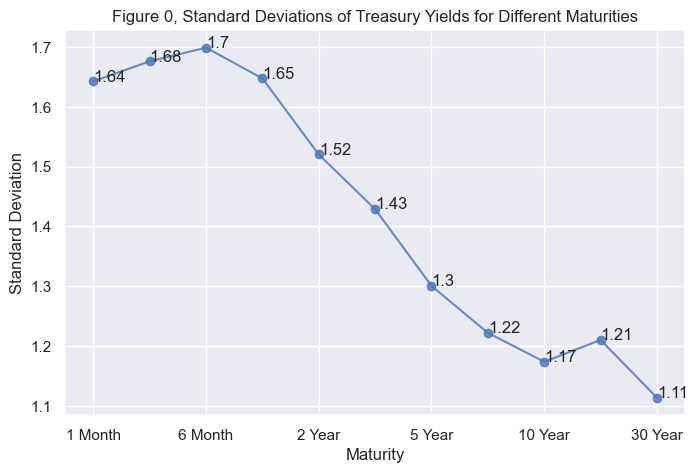

In [ ]:
fig, ax = plt.subplots()
y_std.plot(figsize = (8,5),marker='o', title='Figure 0, Standard Deviations of Treasury Yields for Different Maturities', alpha=0.8) # Plot standard deviations of yields of different maturies
plt.xlabel("Maturity")
plt.ylabel("Standard Deviation")
for i in range(len(y_std)):
    ax.annotate(str(round(y_std.iloc[i],2)),xy=(i,y_std.iloc[i]))
plt.show()

Figure 3


C:\Users\Keegan Vaughn\AppData\Local\Temp\ipykernel_29860\3684092705.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


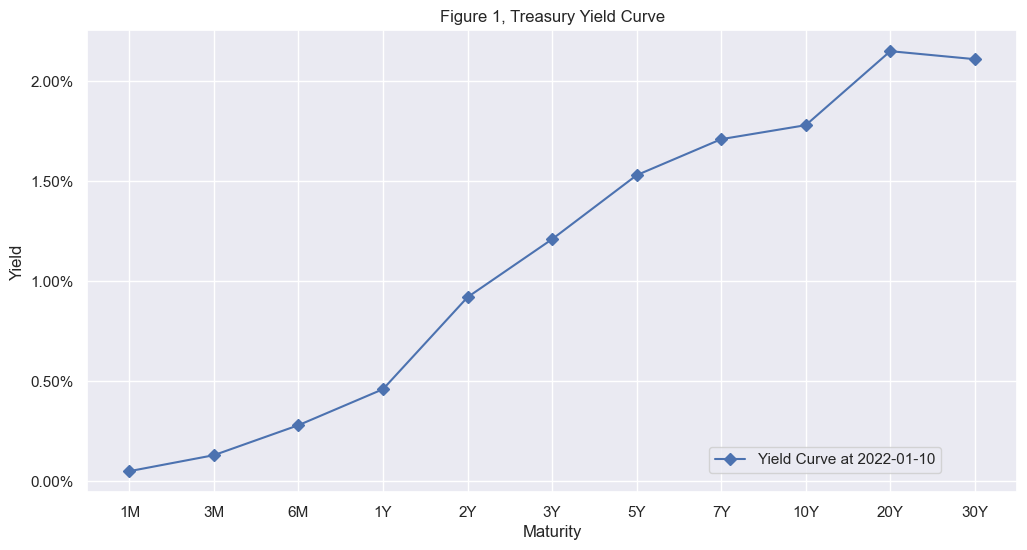

In [ ]:
def plot_yield_curve(date, fig_n):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)

    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    # Add labels and title
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title(fig_n+'Treasury Yield Curve')


    fig.legend(loc = [0.69, 0.14])

    # Show the plot
    plt.grid(True)
    plt.show()

print("Figure 3")
plot_yield_curve('2022-01-10','Figure 1, ')

In [ ]:
! pip install nelson_siegel_svensson


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: C:\Users\Keegan Vaughn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [41]:
# Create maturity and yield variables in array form
t = np.array([0.08333,0.25,0.5,1,2,3,5,7,10,20,30])
y = np.array(yields.loc["2022-01-10"])

In [42]:
# Fit an NS model for yields from 2022-01-10
curve, status = calibrate_ns_ols(t, y, tau0=1.0)  # starting value of 1.0 for the optimization of tau
assert status.success
print(curve)

NelsonSiegelCurve(beta0=np.float64(2.255966761126145), beta1=np.float64(-2.2686246787670283), beta2=np.float64(-0.7157988559371846), tau=np.float64(1.2795165925903043))


Text(0.5, 1.0, 'Figure 2, NS Model Result')

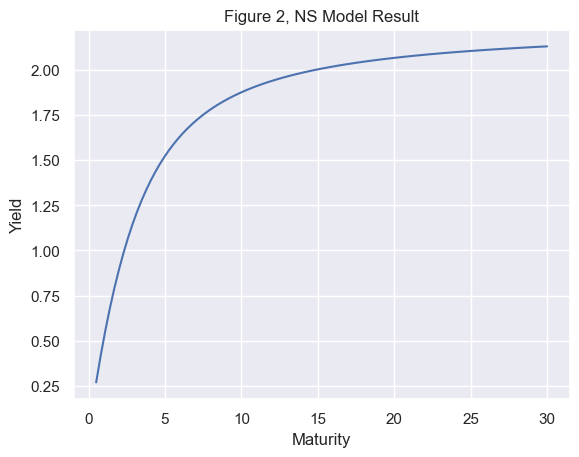

In [ ]:
y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 2, NS Model Result")

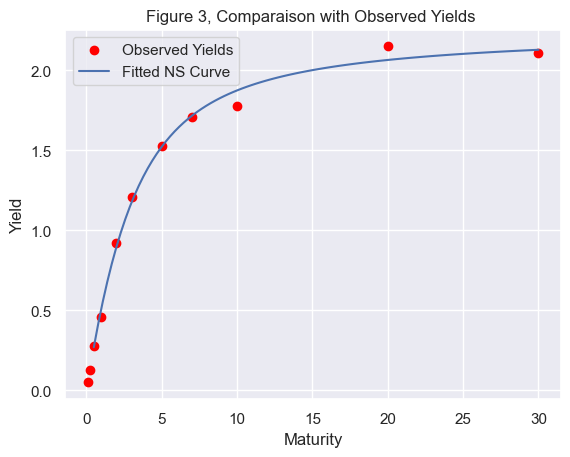

In [ ]:
# Compare with Observed Yields
plt.scatter(t, y, color='red', label='Observed Yields')
plt.plot(t_hat, y_hat(t_hat), label='Fitted NS Curve')
plt.title("Figure 3, Comparaison with Observed Yields ")
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.legend()
plt.show()

C:\Users\Keegan Vaughn\AppData\Local\Temp\ipykernel_29860\3684092705.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


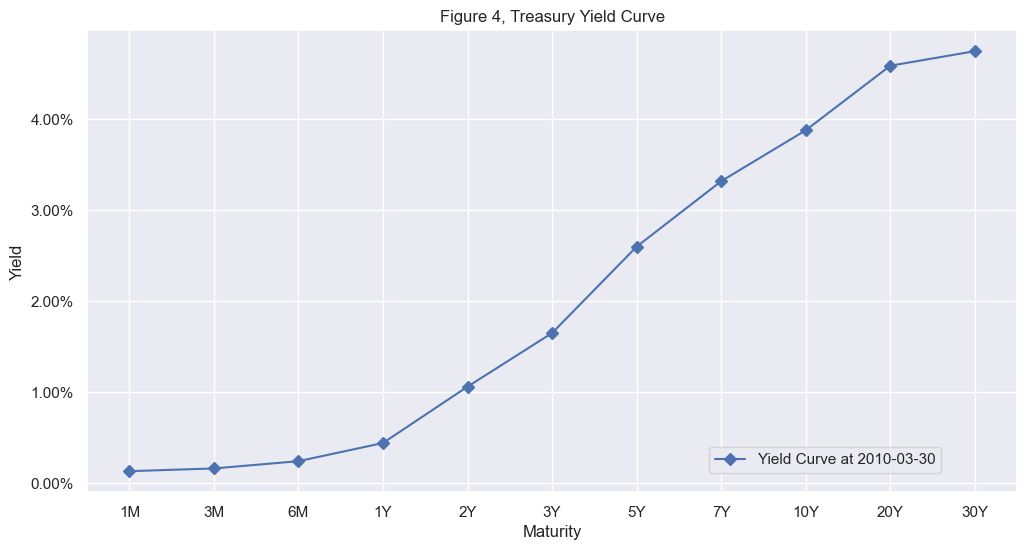

In [ ]:
plot_yield_curve('2010-03-30','Figure 4, ')

In [46]:
y = np.array(yields.loc["2010-03-30"])
curve, status = calibrate_ns_ols(t, y, tau0=0.5)  # starting value of 0.5 for the optimization of tau
assert status.success
print(curve)

NelsonSiegelCurve(beta0=np.float64(5.267741296552761), beta1=np.float64(-5.1303981920275215), beta2=np.float64(-5.174474027193151), tau=np.float64(1.375041075769324))


Text(0.5, 1.0, 'Figure 5, NS Model Result')

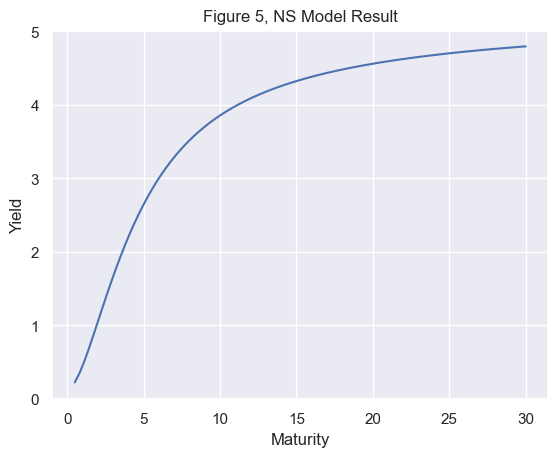

In [47]:
y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 5, NS Model Result")

In [48]:
yields.loc["2022-01-10"]

1 Month    0.05
3 Month    0.13
6 Month    0.28
1 Year     0.46
2 Year     0.92
3 Year     1.21
5 Year     1.53
7 Year     1.71
10 Year    1.78
20 Year    2.15
30 Year    2.11
Name: 2022-01-10 00:00:00, dtype: float64

In [49]:
t = np.array([2,5,10,30])
y = np.array([1.56,1.63,1.83,2.28])

In [50]:
# Create output vector y (out variable) and squared matrix A (input variable)
out = np.array([1.56,1.63,1.63,1.83,1.83,2.28,0,0,0,0,0,0])
input = np.array([[8,4,2,1,0,0,0,0,0,0,0,0],[125,25,5,1,0,0,0,0,0,0,0,0],[0,0,0,0,125,25,5,1,0,0,0,0],[0,0,0,0,1000,100,10,1,0,0,0,0], \
                  [0,0,0,0,0,0,0,0,1000,100,10,1],[0,0,0,0,0,0,0,0,27000,900,30,1],[75,10,1,0,-75,-10,-1,0,0,0,0,0],[0,0,0,0,300,20,1,0,-300,-20,-1,0], \
                  [30,2,0,0,-30,-2,0,0,0,0,0,0],[0,0,0,0,60,2,0,0,-60,-2,0,0],[12,2,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,180,2,0,0]])

In [51]:
# Solve for coefficient vector and reshape to an 3 by 4 array (lines variable)
# Make sure to give enough decimals since all coefficients are relatively small. If there is not decimal points, the following coefficient results and graphs will be rough
lines = np.round(np.dot(np.linalg.inv(input), out).reshape(-1,4),decimals=8)
lines

array([[ 3.96060000e-04, -2.37634000e-03,  2.45215100e-02,
         1.51729391e+00],
       [-3.31400000e-04,  8.53548000e-03, -3.00376300e-02,
         1.60822581e+00],
       [ 2.34400000e-05, -2.10968000e-03,  7.64139800e-02,
         1.25338710e+00]])

In [52]:
# Calculates x**0 + x**1 + x**2 + x**3
def plot_num(values, coeffs):
    # Coeffs are assumed to be in order 0, 1, ..., n-1
    expanded = np.hstack([coeffs[i] * (values ** i) for i in range(0, len(coeffs))])
    return np.sum(expanded, axis=1)

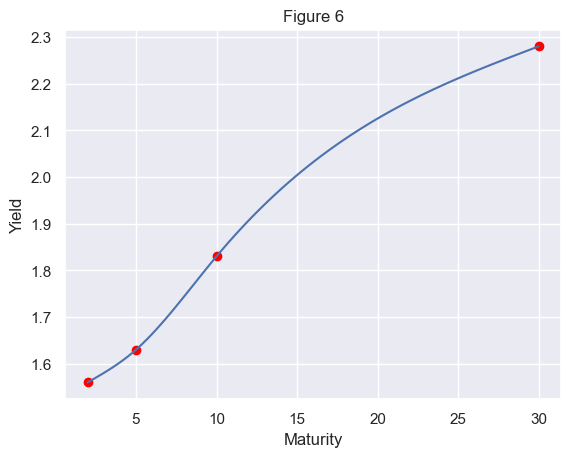

In [ ]:
# Simulate the 100 paired data points and draw the graph
xs = np.linspace(2,30, 100)

y1s = plot_num(xs[xs<5].reshape(-1,1), lines[0][::-1])
y2s = plot_num(xs[(xs>=5) & (xs<10)].reshape(-1,1), lines[1][::-1])
y3s = plot_num(xs[xs>=10].reshape(-1,1), lines[2][::-1])
ys = np.concatenate([y1s, y2s, y3s])


plt.plot(xs, ys)
plt.scatter(t, y,c="red")
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("Figure 6")
plt.show()

Task 3: Exploiting Correlation

In [62]:
# Task 3
from sklearn.decomposition import PCA
import numpy as np
import yfinance as yf

#Part A: Generate 5 uncorrelated Gaussian random variables
np.random.seed(500)
n_samples = 1000
mean = 0
std_dev = 0.01
data = np.random.normal(mean, std_dev, (n_samples, 5))

In [63]:
#Part B: Perform PCA using covariance matrix
pca = PCA()
pca.fit(data)

PCA()

In [64]:
#Part C: Variance explained by each component
explained_variance = pca.explained_variance_ratio_
print("Explained Variance (for uncorrelated synthetic data):")
for i, var in enumerate(explained_variance, 1):
    print(f"Component {i}: {var:.4f}")

Explained Variance (for uncorrelated synthetic data):
Component 1: 0.2160
Component 2: 0.2067
Component 3: 0.1957
Component 4: 0.1922
Component 5: 0.1894


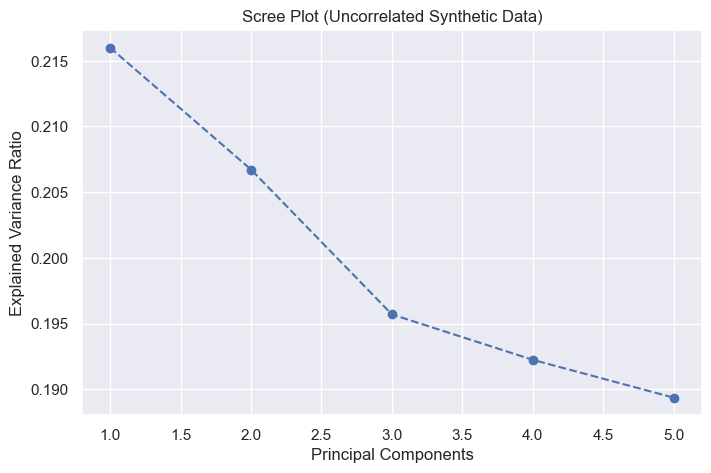

In [ ]:
#Part D: Produce a scree plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), explained_variance, marker='o', linestyle='--')
plt.title("Scree Plot (Uncorrelated Synthetic Data)")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

In [ ]:
#Part E: Collect real data for 5 government securities
tickers = ['^IRX', '^FVX', '^TNX', '^TYX', 'TLT']  # 5 Treasury bond ETFs
data_real = yf.download(tickers, start="2024-07-01", end="2024-12-31")['Close']

[*********************100%***********************]  5 of 5 completed


In [ ]:
#Part F: Compute daily yield changes
yield_changes = data_real.pct_change().dropna() * 100

In [72]:
#Part G: Perform PCA on the yield changes data using covariance matrix
pca_real = PCA()
pca_real.fit(yield_changes)

PCA()

In [73]:
#Part H: Variance explained by each component
explained_variance_real = pca_real.explained_variance_ratio_
print("\nExplained Variance (for real government securities data):")
for i, var in enumerate(explained_variance_real, 1):
    print(f"Component {i}: {var:.4f}")


Explained Variance (for real government securities data):
Component 1: 0.9111
Component 2: 0.0591
Component 3: 0.0220
Component 4: 0.0066
Component 5: 0.0011


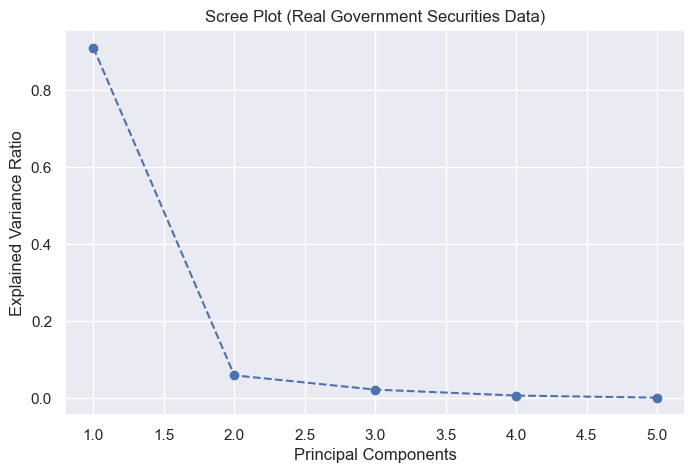

In [74]:
#Part I: Produce a scree plot with real data
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(tickers)+1), explained_variance_real, marker='o', linestyle='--')
plt.title("Scree Plot (Real Government Securities Data)")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

Task 4: Empirical Analysis of ETFs

In [75]:
# Task 4
# Libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Display settings for better view
pd.options.display.float_format = '{:.4f}'.format

# Question: a. Find the 30 largest holdings.
# The ticker symbols for the top 30 XLRE holdings
tickers = [
    "PLD","EXR", "AVB", "VICI", "CSGP", "AMT", "EQIX", "WELL", "DLR", "SPG", 
    "O", "PSA", "CBRE", "CCI", "IRM", "VTR", "EQR", "SBAC", "WY", "ESS","ARE",
    "KIM", "SLG", "UDR", "CPT", "INVH", "MAA",  "HST", "REG", "BXP"
]

# Historical data from first July 2024 to first of January 2025
data = yf.download(tickers, start="2024-07-01", end="2025-01-01")['Close']

#print(data)

# Check the data
data.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AMT,ARE,AVB,BXP,CBRE,CCI,CPT,CSGP,DLR,EQIX,...,PSA,REG,SBAC,SLG,SPG,UDR,VICI,VTR,WELL,WY
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-01,190.9225,113.0197,201.2094,59.1615,85.9700,93.2177,107.3404,73.8800,149.9893,752.2147,...,278.1391,60.7297,188.0846,53.8258,143.0412,39.8069,27.1561,50.1344,102.8969,27.2100
2024-07-02,189.2005,114.2396,201.0912,59.9998,87.0800,92.5475,107.0848,74.2200,150.7583,748.9472,...,280.3593,60.8672,187.3116,54.3935,144.2713,39.7584,27.0295,51.0311,104.8460,27.1310
2024-07-03,191.6802,114.2688,197.8907,59.9316,87.3900,93.8781,105.6791,73.8300,149.5752,741.6397,...,282.2749,60.5138,190.4632,55.2353,144.7399,39.3801,27.0101,51.0606,104.2326,26.7064
2024-07-05,192.5166,113.9858,200.1754,58.7813,87.2100,93.3051,105.8953,73.1500,149.3090,747.0757,...,284.5638,60.8181,189.1252,53.8356,142.6214,39.6420,27.0101,51.6814,105.3506,27.1013
2024-07-08,193.0382,113.8394,200.0277,59.2200,88.3600,93.8393,106.2001,72.6300,151.4977,749.4818,...,285.3203,60.6119,192.2272,54.6969,143.3829,39.5935,27.0879,51.1198,103.3124,27.2396


In [76]:
#Yfinance daily returns data

yf_daily_returns = data.pct_change().dropna()
yf_daily_returns.head()

Ticker,AMT,ARE,AVB,BXP,CBRE,CCI,CPT,CSGP,DLR,EQIX,...,PSA,REG,SBAC,SLG,SPG,UDR,VICI,VTR,WELL,WY
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-02,-0.0090,0.0108,-0.0006,0.0142,0.0129,-0.0072,-0.0024,0.0046,0.0051,-0.0043,...,0.0080,0.0023,-0.0041,0.0105,0.0086,-0.0012,-0.0047,0.0179,0.0189,-0.0029
2024-07-03,0.0131,0.0003,-0.0159,-0.0011,0.0036,0.0144,-0.0131,-0.0053,-0.0078,-0.0098,...,0.0068,-0.0058,0.0168,0.0155,0.0032,-0.0095,-0.0007,0.0006,-0.0059,-0.0156
2024-07-05,0.0044,-0.0025,0.0115,-0.0192,-0.0021,-0.0061,0.0020,-0.0092,-0.0018,0.0073,...,0.0081,0.0050,-0.0070,-0.0253,-0.0146,0.0067,0.0000,0.0122,0.0107,0.0148
2024-07-08,0.0027,-0.0013,-0.0007,0.0075,0.0132,0.0057,0.0029,-0.0071,0.0147,0.0032,...,0.0027,-0.0034,0.0164,0.0160,0.0053,-0.0012,0.0029,-0.0109,-0.0193,0.0051
2024-07-09,-0.0011,-0.0052,0.0034,0.0084,0.0046,0.0046,-0.0002,-0.0143,-0.0023,0.0131,...,-0.0050,0.0055,0.0081,0.0179,0.0048,-0.0002,-0.0068,0.0069,0.0039,-0.0007


In [77]:
# Calculate Daily Returns
# Percentage change removes NaN from the first row
daily_returns = yf_daily_returns.pct_change().dropna() 


# Display a snippet of daily returns
daily_returns.head()

Ticker,AMT,ARE,AVB,BXP,CBRE,CCI,CPT,CSGP,DLR,EQIX,...,PSA,REG,SBAC,SLG,SPG,UDR,VICI,VTR,WELL,WY
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-03,-2.4531,-0.9763,26.0907,-1.0803,-0.7243,-2.9999,4.5132,-2.1418,-2.5306,1.2462,...,-0.1440,-3.5656,-5.0938,0.4673,-0.6223,6.8091,-0.8454,-0.9676,-1.3089,4.3905
2024-07-05,-0.6671,-10.6650,-1.7254,15.8762,-1.5786,-1.4246,-1.1559,0.7528,-0.7732,-1.7512,...,0.1868,-1.8661,-1.4175,-2.6374,-5.5062,-1.6990,-1.0000,19.9880,-2.8333,-1.9450
2024-07-08,-0.3792,-0.4814,-1.0639,-1.3888,-7.4021,-1.9379,0.4061,-0.2282,-9.2363,-0.5606,...,-0.6722,-1.6740,-3.3349,-1.6314,-1.3648,-1.1840,inf,-1.8939,-2.8037,-0.6551
2024-07-09,-1.3951,3.0717,-5.6700,0.1249,-0.6481,-0.2046,-1.0643,1.0143,-1.1598,3.0652,...,-2.8782,-2.6246,-0.5065,0.1185,-0.1073,-0.7998,-3.3682,-1.6385,-1.2030,-1.1421
2024-07-10,-4.8612,-2.4832,-1.1424,0.1083,1.8648,0.6742,-49.5284,-1.2439,-7.4874,-0.0906,...,0.1021,-0.3565,-1.2148,-0.6562,0.2369,-27.7922,-2.3248,-1.3586,-1.6802,-1.5004


In [78]:
# Computing the Covariance Matrix
yf_Covariance_matrix = yf_daily_returns.cov()

# Display the covariance matrix (truncated for clarity)
# Showing a subset of the matrix for brevity
yf_Covariance_matrix.iloc[:10, :10] 

Ticker,AMT,ARE,AVB,BXP,CBRE,CCI,CPT,CSGP,DLR,EQIX
Ticker,,,,,,,,,,
AMT,0.0003,0.0001,0.0001,0.0001,0.0001,0.0002,0.0001,0.0001,0.0001,0.0001
ARE,0.0001,0.0003,0.0001,0.0002,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
AVB,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
BXP,0.0001,0.0002,0.0001,0.0003,0.0002,0.0001,0.0001,0.0002,0.0001,0.0001
CBRE,0.0001,0.0001,0.0001,0.0002,0.0003,0.0001,0.0001,0.0002,0.0001,0.0001
CCI,0.0002,0.0001,0.0001,0.0001,0.0001,0.0002,0.0001,0.0001,0.0001,0.0001
CPT,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001
CSGP,0.0001,0.0001,0.0001,0.0002,0.0002,0.0001,0.0001,0.0003,0.0001,0.0001
DLR,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0003,0.0002


In [79]:
# Assuming `yf_daily_returns` is the DataFrame containing the daily returns of the stocks.

# Computing PCA
# Initializing PCA and fitting it to the covariance matrix
pca = PCA()
pca.fit(yf_daily_returns)

# Extract PCA results
# Quantify the variance explained by each principal component.
eigenvalues = pca.explained_variance_  

# Variance explained by each principal component
# 
explained_variance_ratio = pca.explained_variance_ratio_  

# Proportion of variance explained
# Principal components (axes) that describe the directions of maximum variance.
eigenvectors = pca.components_ 

# Display PCA results
print("Eigenvalues (Explained Variance):")
print(eigenvalues)
print("\nExplained Variance Ratio:")
print(explained_variance_ratio)
print("\nPrincipal Components (Eigenvectors):")
print(eigenvectors)

# Question F: Computing SVD
# Converting the daily_returns DataFrame into a NumPy array for numerical operations.
returns_matrix = yf_daily_returns.values

# Compute the SVD
# U (Left Singular Vectors): Basis for the row space (time dimension).
# Sigma (Singular Values): Square roots of the eigenvalues of the covariance matrix, representing the magnitude of variance along each principal component.
# VT (Right Singular Vectors): Basis for the column space (stock dimension).
U, Sigma, VT = np.linalg.svd(returns_matrix, full_matrices=False)

# Results
print("\nU (Left Singular Vectors):")
print(U)
print("\nSigma (Singular Values):")
print(Sigma)
print("\nVT (Right Singular Vectors):")
print(VT)

# Comparing PCA and SVD
# The squared singular values (Sigma^2) from SVD are proportional to the eigenvalues from PCA
# Computing the squared singular values normalized by degrees of freedom.
singular_values_squared = Sigma**2 / (len(yf_daily_returns) - 1)  

# Normalize by degrees of freedom
print("\nSingular Values Squared (from SVD):")
print(singular_values_squared)
print("\nEigenvalues (from PCA):")
print(eigenvalues)

Eigenvalues (Explained Variance):
[3.03895238e-03 6.20027691e-04 5.20616795e-04 3.67320133e-04
 2.61947452e-04 2.13940535e-04 1.83475297e-04 1.40727734e-04
 1.19123837e-04 1.06220050e-04 8.79801528e-05 8.05072350e-05
 7.14241896e-05 6.76290119e-05 6.30319112e-05 5.13665052e-05
 4.81129177e-05 4.56235008e-05 4.18375584e-05 3.72420653e-05
 3.17531444e-05 2.76442316e-05 2.41416568e-05 2.12445148e-05
 1.74392597e-05 1.65454038e-05 1.11448297e-05 8.21669069e-06
 8.17164549e-06 6.63985847e-06]

Explained Variance Ratio:
[0.47932639 0.09779542 0.08211559 0.05793649 0.04131632 0.03374431
 0.0289391  0.02219663 0.01878911 0.01675382 0.01387689 0.01269821
 0.01126556 0.01066696 0.00994187 0.00810191 0.00758873 0.00719608
 0.00659893 0.0058741  0.00500834 0.00436026 0.0038078  0.00335084
 0.00275065 0.00260967 0.00175785 0.001296   0.00128889 0.00104729]

Principal Components (Eigenvectors):
[[ 1.99142009e-01  2.07789678e-01  1.66510862e-01  2.48796024e-01
   2.14590955e-01  1.65198992e-01  1.554